# A LEARNING MODEL ON CUSTOMER CHURN FORECASTING FOR TELECOM PROVIDERS

In [ ]:
#----------------------------------------------------------------------------------------
#-----------------Section A: Data Preprocessing------------------------------------------
#----------------------------------------------------------------------------------------

In [ ]:

# Step 1: Import relevant libraries---------------------------------------------------------

#Standard libraries for data analysis:----------------------

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm, skew
from scipy import stats
import statsmodels.api as sm

#Standard libraries for data visualization---------------------

import seaborn as sn
from matplotlib import pyplot
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib
%matplotlib inline
color = sn.color_palette()
import matplotlib.ticker as mtick
from IPython.display import display
pd.options.display.max_columns = None
from pandas.plotting import scatter_matrix

#Miscellaneous Utilitiy Libraries--------------------------------------

import random
import os
import re
import sys
import timeit
import string
import time
from datetime import datetime
from time import time
from dateutil.parser import parse

In [ ]:
# Step 2: Set up current working directory (VS Code version) ------------------------------
import os
print("Current working directory:", os.getcwd())
# Make sure 'customer_churn_data.csv' is in this same folder.


Mounted at /content/drive


In [ ]:
# Step 3: Import the dataset--------------------------------------------------------
import pandas as pd
dataset = pd.read_csv("customer_churn_data.csv")
print("Dataset shape:", dataset.shape)


In [ ]:
# Step 4: Evaluate Datastructure --------------------------------------------------------

dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
dataset.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
dataset.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [ ]:
dataset.isna().any()

customerID          False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool

In [ ]:
# Unique values in each categorical variable: ['state', 'area_code', 'international_plan', 'voice_mail_plan', 'churn']
dataset["PaymentMethod"].nunique(), dataset["PaymentMethod"].unique()

(4,
 array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
        'Credit card (automatic)'], dtype=object))

In [ ]:
dataset["Contract"].nunique(), dataset["Contract"].unique()

(3, array(['Month-to-month', 'One year', 'Two year'], dtype=object))

In [ ]:
dataset["Churn"].nunique() , dataset["Churn"].unique()

(2, array(['No', 'Yes'], dtype=object))

In [ ]:
#Step 5: Check Target Variable Distribution -----------------------------------------------
dataset["Churn"].value_counts()

# ======================================================================================================
#In this case, we have class imbalance with few negatives. In our business challenge,
#false negatives are costly. Hence let's keep an eye onto the Precision, Recall & F2 score besides accuracy
# ======================================================================================================

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
#Step 6: Clean the Dataset----------------------------------------------------------------------

dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'],errors='coerce')
dataset['TotalCharges'] = dataset['TotalCharges'].astype("float")

In [ ]:
#Step 7: Take care of missing data---------------------------------------------------------------

dataset.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  \
0              No  No phone service             DSL             No   
1             Yes                No             DSL            Yes   
2             Yes                No             DSL            Yes   
3              No  No phone service             DSL            Yes   
4             Yes                No     Fiber optic             No   
...           ...               ...             ...            ...   
7038          Yes               Yes             DSL            Yes   
7039          Yes               Yes     Fiber optic             No   
7040           No  No phone service             DSL            Yes   
7041          Yes               Yes     Fiber optic             No   
7042          Yes                No     Fiber optic            Yes   

     OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies  \
0             Yes               No          No          No              No   
1              No              Yes          No          No              No   
2             Yes               No          No          No              No   
3              No              Yes         Yes          No              No   
4              No               No          No          No              No   
...           ...              ...         ...         ...             ...   
7038           No              Yes         Yes         Yes             Yes   
7039          Yes              Yes          No         Yes             Yes   
7040           No               No          No          No              No   
7041           No               No          No          No              No   
7042           No              Yes         Yes         Yes             Yes   

            Contract PaperlessBilling              PaymentMethod  \
0     Month-to-month              Yes           Electronic check   
1           One year               No               Mailed check   
2     Month-to-month              Yes               Mailed check   
3           One year               No  Bank transfer (automatic)   
4     Month-to-month              Yes           Electronic check   
...              ...              ...                        ...   
7038        One year              Yes               Mailed check   
7039        One year              Yes    Credit card (automatic)   
7040  Month-to-month              Yes           Electronic check   
7041  Month-to-month              Yes               Mailed check   
7042        Two year              Yes  Bank transfer (automatic)   

      MonthlyCharges  TotalCharges Churn  
0              29.85         29.85    No  
1              56.95       1889.50    No  
2              53.85        108.15   Yes  
3              42.30       1840.75    No  
4              70.70        151.65   Yes  
...              ...           ...   ...  
7038           84.80       1990.50    No  
7039          103.20       7362.90    No  
7040           29.60        346.45    No  
7041           74.40        306.60   Yes  
7042          105.65       6844.50    No  

[7043 rows x 21

In [ ]:
dataset.isna().any()

customerID          False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges         True
Churn               False
dtype: bool

In [ ]:
#*Find the average and fill missing values of each columns programmatically.
na_cols = dataset.isna().any()

na_cols = na_cols[na_cols == True].reset_index()

na_cols = na_cols["index"].tolist()

for col in dataset.columns[1:]:
     if col in na_cols:
        if dataset[col].dtype != 'object':
             dataset[col] =  dataset[col].fillna(dataset[col].mean()).round(0)


In [ ]:
#Revalidate:
dataset.isna().any()

customerID          False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool

In [ ]:
#Step 8: label Encode Binary data----------------------------------------------------------------
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
#Create a label encoder object
le = LabelEncoder()

# Label Encoding will be used for columns with 2 or less unique values
le_count = 0
for col in dataset.columns[1:]:
    if dataset[col].dtype == 'object':
        if len(list(dataset[col].unique())) <= 2:
            le.fit(dataset[col])
            dataset[col] = le.transform(dataset[col])
            le_count += 1
print('{} columns were label encoded.'.format(le_count))


6 columns were label encoded.


In [ ]:
dataset.dtypes

customerID           object
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [ ]:
#----------------------------------------------------------------------------------------
#-----------------Section B: Data Evaluation------------------------------------------
#----------------------------------------------------------------------------------------


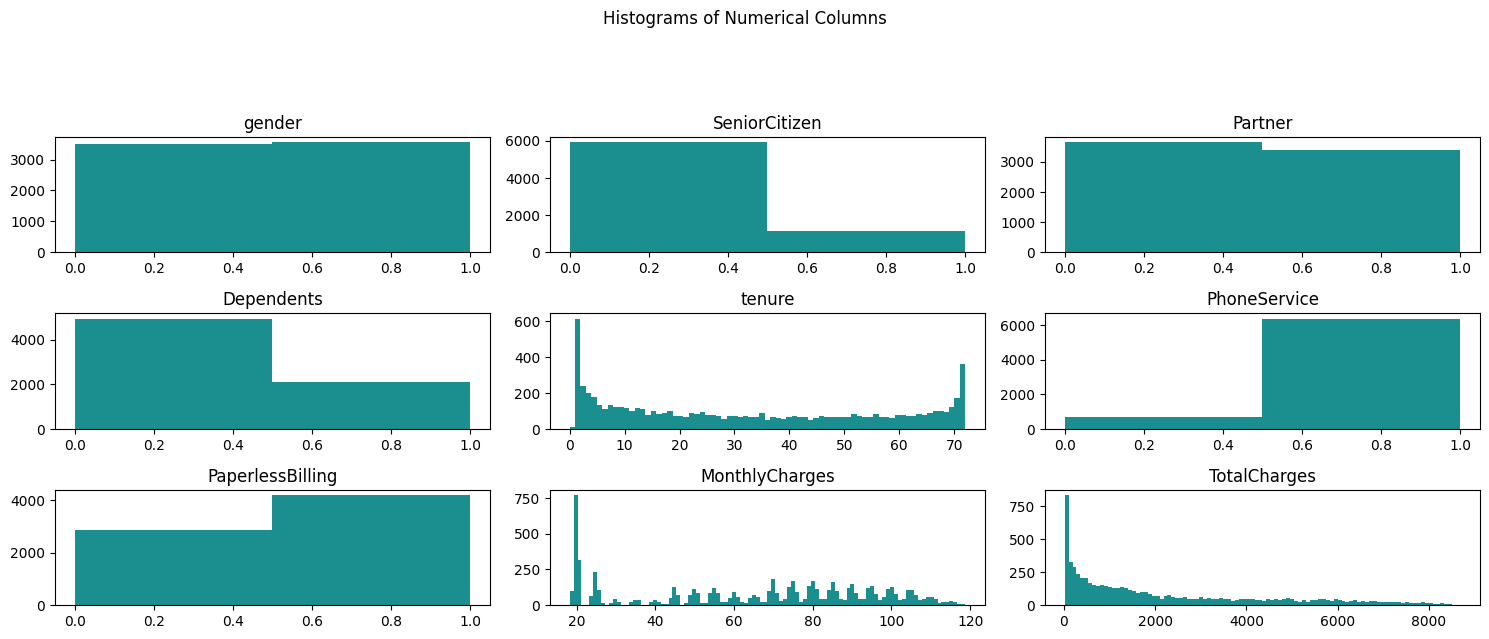

In [ ]:
#Step 9: Exploratory Data Analysis----------------------------------------------------------------------

#Step 9.1. Plot Histogram of numeric Columns--------------------------------------

dataset2 = dataset[['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling',
        'MonthlyCharges', 'TotalCharges']]

#Histogram:

fig = plt.figure(figsize=(15, 12))
plt.suptitle('Histograms of Numerical Columns\n',horizontalalignment="center",fontstyle = "normal", fontsize = 12)
for i in range(dataset2.shape[1]):
    plt.subplot(6, 3, i + 1)
    f = plt.gca()
    f.set_title(dataset2.columns.values[i])

    vals = np.size(dataset2.iloc[:, i].unique())
    if vals >= 100:
        vals = 100

    plt.hist(dataset2.iloc[:, i], bins=vals, color = '#1b8f90')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])



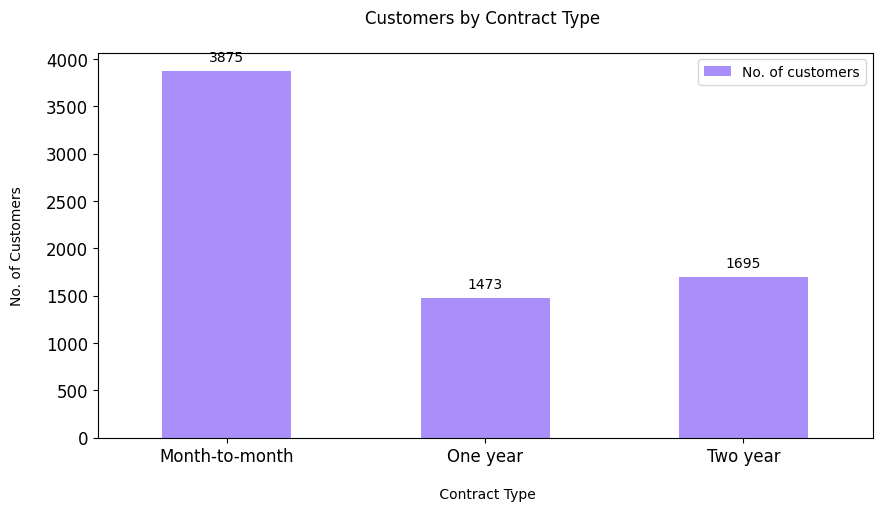

In [ ]:
#Step 9.2. Analyze distribution of Key Categorical Variables---------------------------------------------

#(1) Distribution of Contract Type----------------------------------------------------------------------------------------

contract_split = dataset[[ "customerID", "Contract"]]
sectors = contract_split .groupby ("Contract")
contract_split = pd.DataFrame(sectors["customerID"].count())
contract_split.rename(columns={'customerID':'No. of customers'}, inplace=True)

ax =  contract_split[["No. of customers"]].plot.bar(title = 'Customers by Contract Type', legend =True, table = False, grid = False,  subplots = False,  figsize =(10, 5), color ='#aa8ffa', fontsize = 12, stacked=False)

plt.ylabel('No. of Customers\n',horizontalalignment="center",)
plt.xlabel('\n Contract Type',horizontalalignment="center")
plt.title('Customers by Contract Type \n',horizontalalignment="center")
plt.legend(loc='upper right', fontsize = "medium")
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")

x_labels = np.array(contract_split[["No. of customers"]])

def add_value_labels(ax, spacing=5):
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        space = spacing
        va = 'bottom'
        if y_value < 0:
            space *= -1
            va = 'top'
        label = "{:.0f}".format(y_value)
        ax.annotate(
            label,
            (x_value, y_value),
            xytext=(0, space),
            textcoords="offset points",
            ha='center',
            va=va)
add_value_labels(ax)


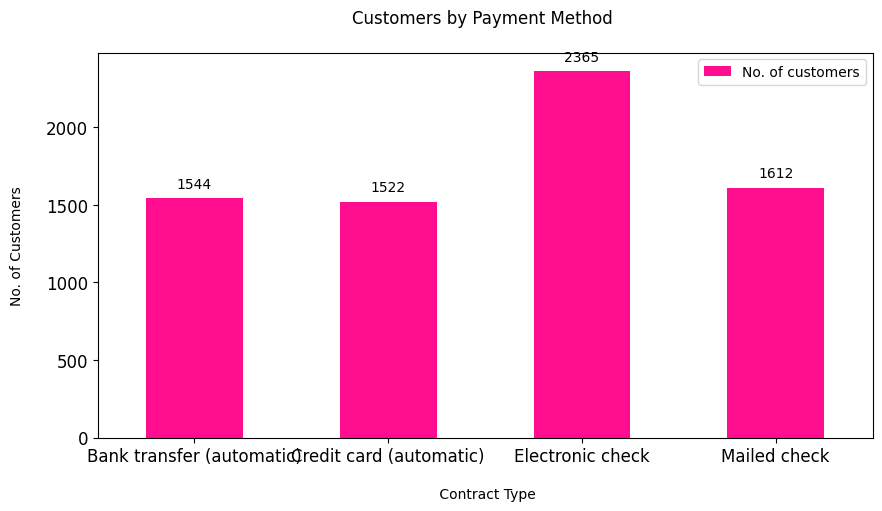

In [ ]:
#(2) Distribution of Payment Method Type---------------------------------------------------------------------------------------

payment_method_split = dataset[[ "customerID", "PaymentMethod"]]
sectors = payment_method_split  .groupby ("PaymentMethod")
payment_method_split  = pd.DataFrame(sectors["customerID"].count())
payment_method_split.rename(columns={'customerID':'No. of customers'}, inplace=True)


ax =  payment_method_split [["No. of customers"]].plot.bar(title = 'Customers by Payment Method', legend =True, table = False, grid = False,  subplots = False,  figsize =(10, 5), color ='#ff0f8f', fontsize = 12, stacked=False)

plt.ylabel('No. of Customers\n',horizontalalignment="center")
plt.xlabel('\n Contract Type',horizontalalignment="center")
plt.title('Customers by Payment Method \n',horizontalalignment="center")
plt.legend(loc='upper right', fontsize = "medium")
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")

x_labels = np.array(payment_method_split [["No. of customers"]])

def add_value_labels(ax, spacing=5):
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        space = spacing
        va = 'bottom'
        if y_value < 0:
            space *= -1
            va = 'top'
        label = "{:.0f}".format(y_value)
        ax.annotate(
            label,
            (x_value, y_value),
            xytext=(0, space),
            textcoords="offset points",
            ha='center',
            va=va)
add_value_labels(ax)


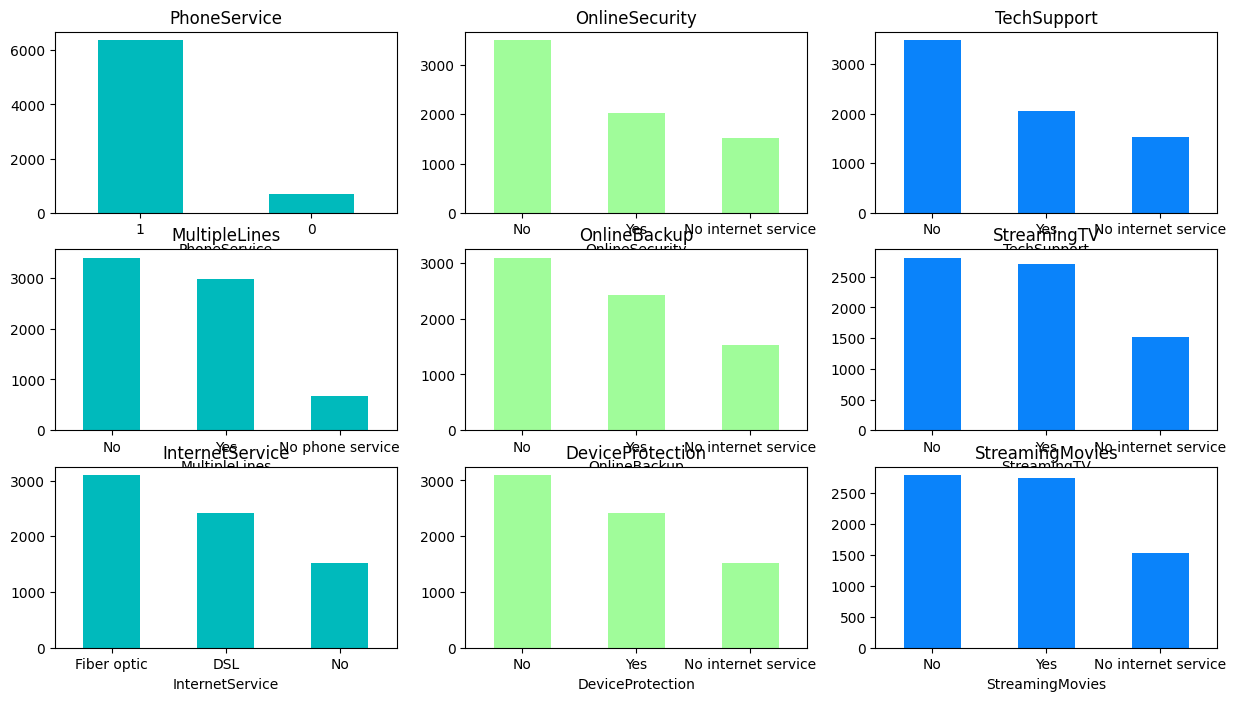

In [ ]:
#(3) Distribution of various Label Encoded Categorical Variables---------------------------------------------------------------------------------------

services = ['PhoneService','MultipleLines','InternetService','OnlineSecurity',
           'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

fig, axes = plt.subplots(nrows = 3,ncols = 3,figsize = (15,8))
for i, item in enumerate(services):
    if i < 3:
        ax = dataset[item].value_counts().plot(kind = 'bar',ax=axes[i,0],rot = 0, color ='#00babc' )

    elif i >=3 and i < 6:
        ax = dataset[item].value_counts().plot(kind = 'bar',ax=axes[i-3,1],rot = 0,color ='#a0fc9a')

    elif i < 9:
        ax = dataset[item].value_counts().plot(kind = 'bar',ax=axes[i-6,2],rot = 0,color = '#0a83fa')
    ax.set_title(item)


<ipython-input-26-b8d20dbe2558>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  churn_rate ["churn_label"] = pd.Series(np.where((churn_rate["Churn"] == 0), "No", "Yes"))


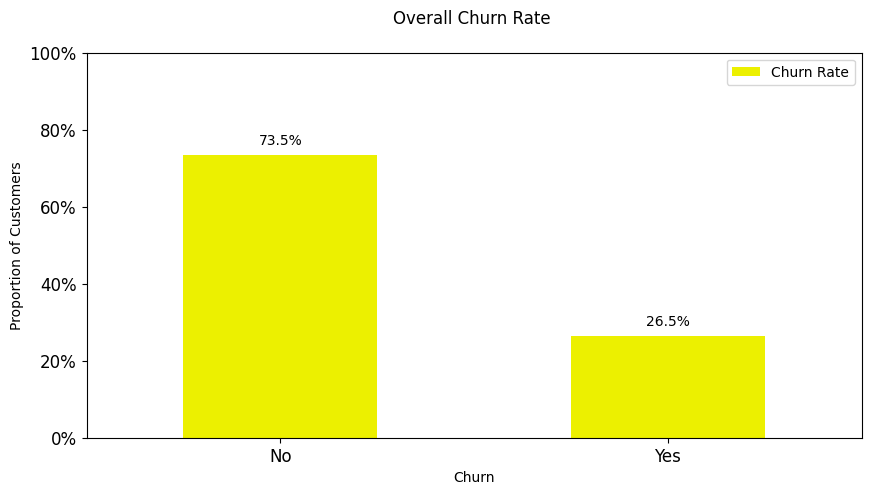

In [ ]:
#Step 9.3: Analyze Churn Rate by Categorical variables:   -------------------------------------------------------------

#(1) Overall Churn Rate------------------------------------------------------------------------------------------

import matplotlib.ticker as mtick
churn_rate = dataset[["Churn", "customerID"]]
churn_rate ["churn_label"] = pd.Series(np.where((churn_rate["Churn"] == 0), "No", "Yes"))
sectors = churn_rate .groupby ("churn_label")
churn_rate = pd.DataFrame(sectors["customerID"].count())
churn_rate ["Churn Rate"] = (churn_rate ["customerID"] / sum(churn_rate ["customerID"]) )*100
ax =  churn_rate[["Churn Rate"]].plot.bar(title = 'Overall Churn Rate', legend =True, table = False, grid = False,  subplots = False,  figsize =(10, 5), color = '#ecf000', fontsize = 12, stacked=False, ylim =(0,100))

plt.ylabel('Proportion of Customers',horizontalalignment="center")
plt.xlabel('Churn',horizontalalignment="center",fontstyle = "normal")
plt.title('Overall Churn Rate \n',horizontalalignment="center")
plt.legend(loc='upper right', fontsize = "medium")
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
x_labels = np.array(churn_rate[["customerID"]])

def add_value_labels(ax, spacing=5):
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        space = spacing
        va = 'bottom'
        if y_value < 0:
            space *= -1
            va = 'top'

        label = "{:.1f}%".format(y_value)
        ax.annotate(
            label,
            (x_value, y_value),
            xytext=(0, space),
            textcoords="offset points",
            ha='center',
            va=va)
add_value_labels(ax)
ax.autoscale(enable=False, axis='both', tight=False)


In [ ]:
# Step 9.4. Find positive and negative correlations with the Response Variable--------------------
dataset2 = dataset[['SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling',
        'MonthlyCharges', 'TotalCharges']]
correlations = dataset2.corrwith(dataset.Churn)
correlations = correlations[correlations!=1]
positive_correlations = correlations[correlations >0].sort_values(ascending = False)
negative_correlations = correlations[correlations<0].sort_values(ascending = False)

print('Most Positive Correlations: \n', positive_correlations)
print('\nMost Negative Correlations: \n', negative_correlations)


Most Positive Correlations: 
 MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PhoneService        0.011942
dtype: float64

Most Negative Correlations: 
 Partner        -0.150448
Dependents     -0.164221
TotalCharges   -0.199426
tenure         -0.352229
dtype: float64


Text(0.5, 1.0, 'Correlation with Churn Rate \n')

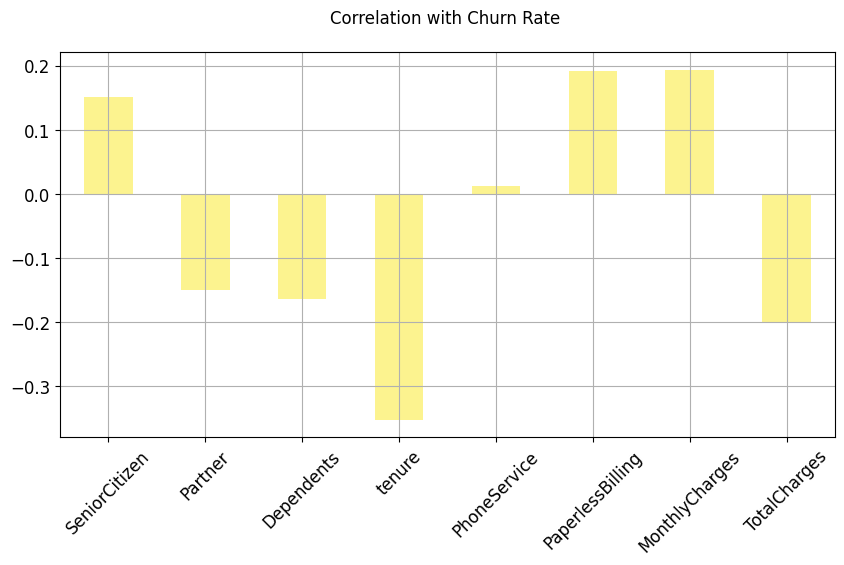

In [ ]:
#Step 10.4. Plot positive & negative correlation with Response Variable-----------------------------

correlations = dataset2.corrwith(dataset.Churn)
correlations = correlations[correlations!=1]

correlations.plot.bar(
        figsize = (10, 5), fontsize = 12, color = '#fcf38f',
        rot = 45, grid = True)

plt.title('Correlation with Churn Rate \n',horizontalalignment="center", fontstyle = "normal", fontsize = "12")


<Axes: >

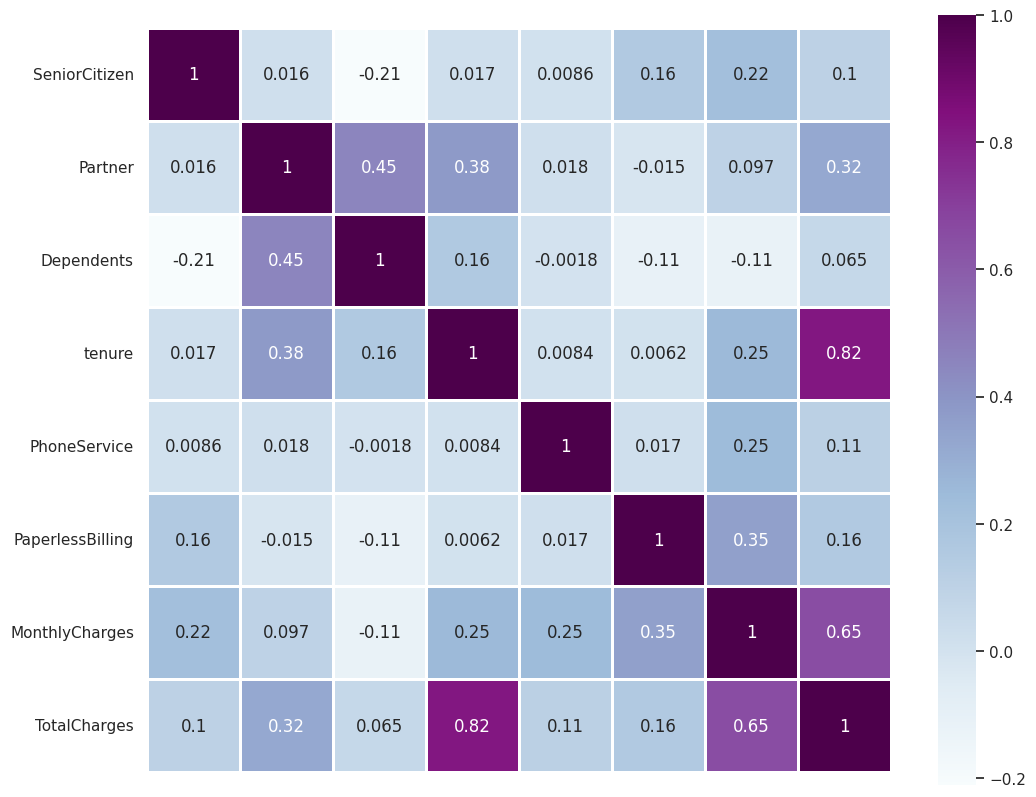

In [ ]:
#Step 9.5. Plot Correlation Matrix of all independent variables------------------------

## Set and compute the Correlation Matrix
sn.set(style="white")
corr = dataset2.corr()

# Set up the matplotlib figure and a diverging colormap
f, ax = plt.subplots(figsize=(12, 10))

# Draw the heatmap with the mask and correct aspect ratio
sn.heatmap(corr, cmap='BuPu', annot=True, square=True, linewidths=2, xticklabels=False)

In [ ]:
#Step 9.6: Check Multicolinearity using Variance Inflation Factor (VIF)----------------------------------------------
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calc_vif(X):

    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

dataset2 = dataset[['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling','MonthlyCharges','TotalCharges']]

calc_vif(dataset2)

,variables,VIF
0,gender,1.921286
1,SeniorCitizen,1.327766
2,Partner,2.815272
3,Dependents,1.921208
4,tenure,10.549667
5,PhoneService,7.976386
6,PaperlessBilling,2.814160
7,MonthlyCharges,13.988649
8,TotalCharges,12.570269


Text(0.5, 1.0, 'Co-linearity of Monthly charges with Total Charges \n')

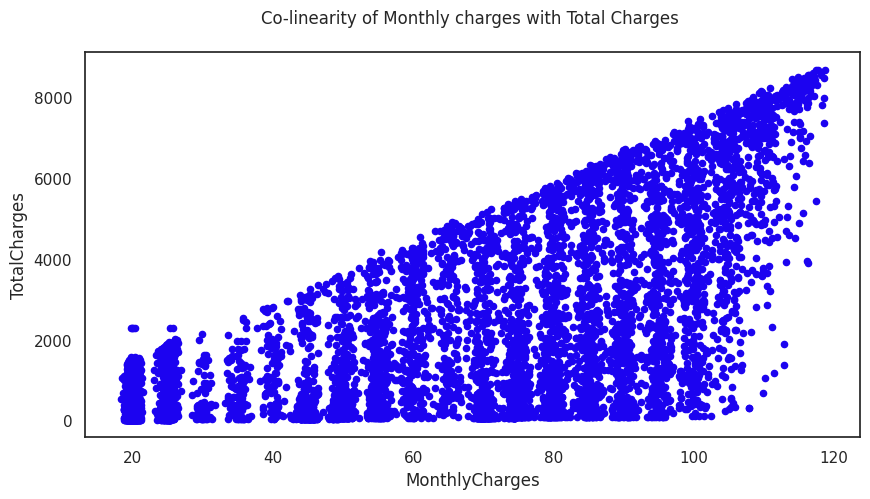

In [ ]:
#Total Charges seem to be colinear with Monthly Charges.

#check colinearity:
dataset2[['MonthlyCharges', 'TotalCharges']].plot.scatter(figsize = (10, 5), x = 'MonthlyCharges',
                                                              y='TotalCharges', color =  '#1c03f0')

plt.title('Co-linearity of Monthly charges with Total Charges \n',horizontalalignment="center", fontstyle = "normal", fontsize = "12")



In [ ]:
#dropping TotalCharges:
dataset2 = dataset2.drop(columns = "TotalCharges")

#Revalidate Colinearity:

dataset2 = dataset[['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling','MonthlyCharges']]
calc_vif(dataset2)


,variables,VIF
0,gender,1.879536
1,SeniorCitizen,1.323089
2,Partner,2.814574
3,Dependents,1.908533
4,tenure,3.287603
5,PhoneService,5.963240
6,PaperlessBilling,2.745897
7,MonthlyCharges,7.453993


In [ ]:
#Applying changes in the main dataset:

dataset = dataset.drop(columns = "TotalCharges")

In [ ]:
#Step 10: Encode Categorical data----------------------------------------------------------------

#Incase if user_id is an object:

identity = dataset["customerID"]

dataset = dataset.drop(columns="customerID")

# convert rest of categorical variable into dummy

dataset= pd.get_dummies(dataset)

#Rejoin userid to dataset (column concatenation)

dataset = pd.concat([dataset, identity], axis = 1)


In [ ]:
dataset.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,customerID
0,0,0,1,0,1,0,1,29.85,0,False,True,False,True,False,False,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False,7590-VHVEG
1,1,0,0,0,34,1,0,56.95,0,True,False,False,True,False,False,False,False,True,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,5575-GNVDE
2,1,0,0,0,2,1,1,53.85,1,True,False,False,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True,3668-QPYBK
3,1,0,0,0,45,0,0,42.30,0,False,True,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,False,True,False,True,False,False,False,7795-CFOCW
4,0,0,0,0,2,1,1,70.70,1,True,False,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False,9237-HQITU


In [ ]:
#Step 11: Split dataset into dependent and independent variables-----------------------------------

#identify response variable:

response = dataset["Churn"]

dataset = dataset.drop(columns="Churn")


In [ ]:
#Step 12: Generate training and test datasets of dependent and independent variables-----------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(dataset, response, stratify=response, test_size = 0.2, random_state = 0)

print("Number transactions X_train dataset: ", X_train.shape)
print("Number transactions y_train dataset: ", y_train.shape)
print("Number transactions X_test dataset: ", X_test.shape)
print("Number transactions y_test dataset: ", y_test.shape)


Number transactions X_train dataset:  (5634, 40)
Number transactions y_train dataset:  (5634,)
Number transactions X_test dataset:  (1409, 40)
Number transactions y_test dataset:  (1409,)


In [ ]:
# Step 13: Removing Identifiers-------------------------------------------------------------------

train_identity = X_train['customerID']
X_train = X_train.drop(columns = ['customerID'])

test_identity = X_test['customerID']
X_test = X_test.drop(columns = ['customerID'])

In [ ]:
# Step 14: Feature Scaling-----------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train2 = pd.DataFrame(sc_X.fit_transform(X_train))
X_train2.columns = X_train.columns.values
X_train2.index = X_train.index.values
X_train = X_train2

X_test2 = pd.DataFrame(sc_X.transform(X_test))
X_test2.columns = X_test.columns.values
X_test2.index = X_test.index.values
X_test = X_test2

In [ ]:
#----------------------------------------------------------------------------------------
#-----------------Section C: Model Selection---------------------------------------------
#----------------------------------------------------------------------------------------

In [ ]:
#Step 15.1: Compare Baseline Classification Algorithms - First Iteration
#Using Accuracy and ROC AUC Mean Metrics
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = []

models.append(('Logistic Regression', LogisticRegression(solver='liblinear', random_state = 0, class_weight='balanced')))

models.append(('SVC', SVC(kernel = 'linear', random_state = 0)))

models.append(('Gaussian NB', GaussianNB()))

models.append(('Decision Tree Classifier', DecisionTreeClassifier(criterion = 'entropy', random_state = 0)))

models.append(('Random Forest', RandomForestClassifier(n_estimators=100, criterion = 'entropy', random_state = 0)))

#Evaluating Model Results:

acc_results = []
auc_results = []
names = []
# set table to table to populate with performance results
col = ['Algorithm', 'ROC AUC Mean', 'ROC AUC STD', 'Accuracy Mean', 'Accuracy STD']

model_results = pd.DataFrame({"Algorithm":pd.Series(dtype='str'),
                              "ROC AUC Mean" : pd.Series (dtype='float'),
                              "ROC AUC STD" : pd.Series (dtype='float'),
                              "Accuracy Mean" : pd.Series (dtype='float'),
                              "Accuracy STD" : pd.Series (dtype='float')})
#, "ROC AUC STD", "Accuracy Mean", "Accuracy STD"])

In [ ]:
from sklearn import model_selection
i = 0
# evaluate each model using k-fold cross-validation
for name, model in models:
    kfold = model_selection.KFold(
        n_splits=10)  # 10-fold cross-validation

    cv_acc_results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')   # accuracy scoring

    cv_auc_results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold, scoring='roc_auc')    # roc_auc scoring

    acc_results.append(cv_acc_results)
    auc_results.append(cv_auc_results)
    names.append(name)
    model_results.loc[i] = [name,
                         round(cv_auc_results.mean()*100, 2),
                         round(cv_auc_results.std()*100, 2),
                         round(cv_acc_results.mean()*100, 2),
                         round(cv_acc_results.std()*100, 2)
                         ]
    i += 1

model_results.sort_values(by=['ROC AUC Mean'], ascending=False)

,Algorithm,ROC AUC Mean,ROC AUC STD,Accuracy Mean,Accuracy STD
0,Logistic Regression,84.12,1.65,74.60,1.26
1,SVC,83.64,1.68,79.98,1.08
2,Gaussian NB,81.82,1.79,68.99,1.46
4,Random Forest,81.72,2.02,78.47,1.57
3,Decision Tree Classifier,65.44,1.67,72.75,1.45


In [ ]:
#------------------------------------------------------------------------------------------
#Compare Baseline Classification Algorithms - Second Iteration
#Using Accuracy, Precision, Recall, F1 and F2 Score Metrics
#-------------------------------------------------------------------------------------------

In [ ]:
#Step 15.3. Get the right parameters for the baseline models:---------------------------

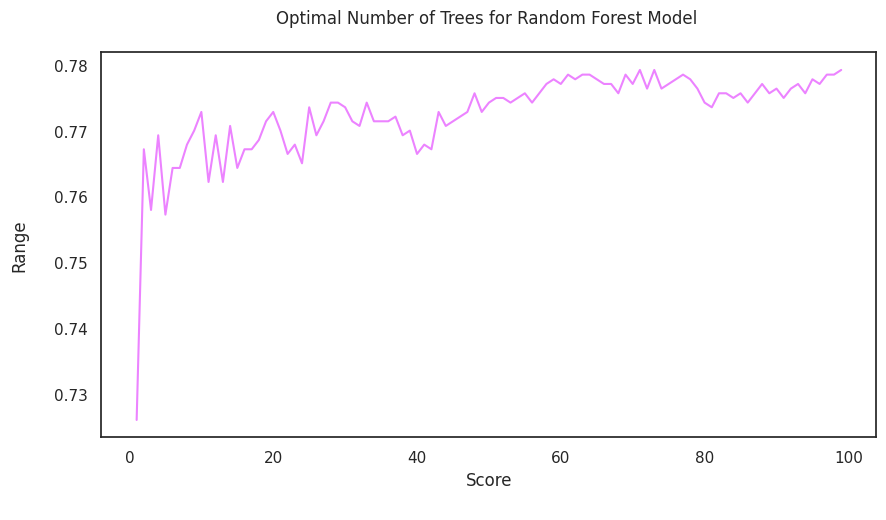

Maximum accuracy:- 0.7792760823278921 at Number of decision trees = 70


In [ ]:
#Identify optimal number of trees for Random Forest Model:

score_array = []
for each in range(1,100):
    rf_loop = RandomForestClassifier(n_estimators = each, random_state = 1)
    rf_loop.fit(X_train,y_train)
    score_array.append(rf_loop.score(X_test,y_test))

fig = plt.figure(figsize=(10, 5))
plt.plot(range(1,100),score_array, color = '#ec83ff')

plt.ylabel('Range\n',horizontalalignment="center")
plt.xlabel('Score\n',horizontalalignment="center")
plt.title('Optimal Number of Trees for Random Forest Model \n',horizontalalignment="center")
#plt.legend(loc='top right', fontsize = "medium")
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")
plt.show()

print("Maximum accuracy:-",max(score_array),"at Number of decision trees =",score_array.index(max(score_array)))

#Optimal number of decision trees = 70

In [ ]:
#Step 15.4. Compare Baseline Classification Algorithms - Second Iteration-----------------------------

In [ ]:
#--Step 15.4.1. Logistic Regression-----------------
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score, fbeta_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# Fitting Logistic Regression to the Training set
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

#Evaluate results
acc = accuracy_score(y_test, y_pred )
prec = precision_score(y_test, y_pred )
rec = recall_score(y_test, y_pred )
f1 = f1_score(y_test, y_pred )
f2 = fbeta_score(y_test, y_pred, beta=2.0)

results = pd.DataFrame([['Logistic Regression', acc, prec, rec, f1, f2]],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score'])

#Step 15.4.2. . Support Vector Machine (linear classifier)------------------------
# Fitting SVM (SVC class) to the Training set:

classifier = SVC(kernel = 'linear', random_state = 0)
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

#Evaluate results

acc = accuracy_score(y_test, y_pred )
prec = precision_score(y_test, y_pred )
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred )
f2 = fbeta_score(y_test, y_pred, beta=2.0)

model_results = pd.DataFrame([['SVM (Linear)', acc, prec, rec, f1, f2]],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score'])

#results = results.append(model_results, ignore_index = True)
results = pd.concat ([results,model_results], ignore_index=True)

#Step 15.4.5.  Naive Byes------------------------------------------------
# Fitting Naive Byes to the Training set:

classifier = GaussianNB()
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

#Evaluate results
acc = accuracy_score(y_test, y_pred )
prec = precision_score(y_test, y_pred )
rec = recall_score(y_test, y_pred )
f1 = f1_score(y_test, y_pred )
f2 = fbeta_score(y_test, y_pred, beta=2.0)

model_results = pd.DataFrame([['Naive Byes', acc, prec, rec, f1, f2]],
                columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score'])

#results = results.append(model_results, ignore_index = True)
results = pd.concat ([results,model_results],ignore_index=True)
#Step 15.4.6. Decision Tree---------------------------------------------
# Fitting Decision Tree to the Training set:

classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

#Evaluate results
acc = accuracy_score(y_test, y_pred )
prec = precision_score(y_test, y_pred )
rec = recall_score(y_test, y_pred )
f1 = f1_score(y_test, y_pred )
f2 = fbeta_score(y_test, y_pred, beta=2.0)

model_results = pd.DataFrame([['Decision Tree', acc, prec, rec, f1, f2]],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score'])

#results = results.append(model_results, ignore_index = True)
results = pd.concat ([results,model_results],ignore_index=True)

#Step 15.4.7. Random Forest--------------------------------------------
# Fitting Random Forest to the Training set:

classifier = RandomForestClassifier(n_estimators = 84, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

#Evaluate results
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
acc = accuracy_score(y_test, y_pred )
prec = precision_score(y_test, y_pred )
rec = recall_score(y_test, y_pred )
f1 = f1_score(y_test, y_pred )
f2 = fbeta_score(y_test, y_pred, beta=2.0)

model_results = pd.DataFrame([['Random Forest', acc, prec, rec, f1, f2]],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score'])

#results = results.append(model_results, ignore_index = True)
results = pd.concat ([results,model_results],ignore_index=True)

In [ ]:
#Step 15.5. Visualize the results and compare the baseline algorithms----------------------------------

# =======================================================================================================================
#Sort results based on the right classification metric:
#(Accuracy/ROC_AUC / Precision/Recall/F1/F2 scores)

#Since we have class imbalance. When we look into the business challenge,
# our false negatives will be costly and hence we need to Keep an eye onto the Precision, Recall & F2 score besides accuracy
# =======================================================================================================================

results = results.sort_values(["Precision", "Recall", "F2 Score"], ascending = False)
results

,Model,Accuracy,Precision,Recall,F1 Score,F2 Score
0,Logistic Regression,0.803407,0.652038,0.556150,0.600289,0.573003
1,SVM (Linear),0.803407,0.650155,0.561497,0.602582,0.577240
4,Random Forest,0.777857,0.611722,0.446524,0.516229,0.472018
3,Decision Tree,0.739532,0.508997,0.529412,0.519004,0.525199
2,Naive Byes,0.703336,0.467359,0.842246,0.601145,0.725806


In [ ]:
#----------------------------------------------------------------------------------------
#-----------------Section D: Model Evaluation (ADA Boost)----------------------
#----------------------------------------------------------------------------------------

In [ ]:

#Step 16: Train & evaluate Chosen Model---------------------------------------------

# Fit Logistic Regression on the Training dataset:
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

# Predict the Test set results
y_pred = classifier.predict(X_test)

#Evaluate Model Results on Test Set:
acc = accuracy_score(y_test, y_pred )
prec = precision_score(y_test, y_pred )
rec = recall_score(y_test, y_pred )
f1 = f1_score(y_test, y_pred )
f2 = fbeta_score(y_test, y_pred, beta=2.0)

results = pd.DataFrame([['Logistic Regression', acc, prec, rec, f1, f2]],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score'])

print (results, len(y_pred), len(y_test))

                 Model  Accuracy  Precision   Recall  F1 Score  F2 Score
0  Logistic Regression  0.803407   0.652038  0.55615  0.600289  0.573003 1409 1409


In [ ]:
# Re-check k-Fold Cross Validation:

accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Logistic Regression Classifier Accuracy: %0.2f (+/- %0.2f)"  % (accuracies.mean(), accuracies.std() * 2))

Logistic Regression Classifier Accuracy: 0.80 (+/- 0.04)


Text(0.5, 19.049999999999997, 'Predicted label\n')

<Figure size 2800x2000 with 0 Axes>

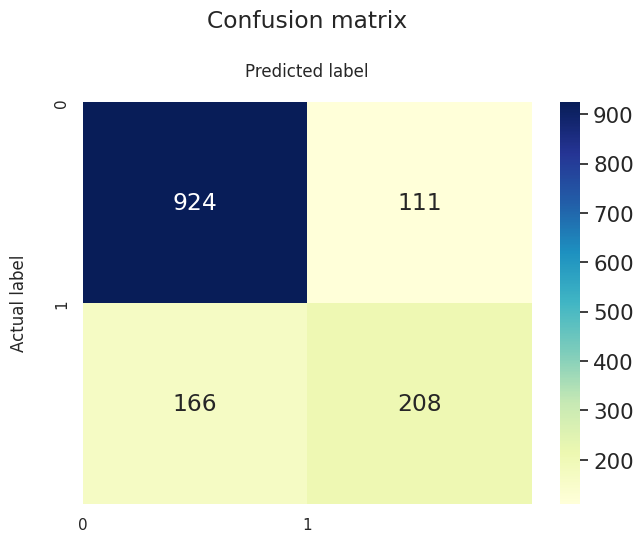

In [ ]:
#Visualize results on a Confusion Matrix:

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index = (0, 1), columns = (0, 1))
plt.figure(figsize = (28,20))


fig, ax = plt.subplots()
sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, fmt='g',cmap="YlGnBu")
class_names=[0,1]
tick_marks = np.arange(len(class_names))
plt.tight_layout()
plt.title('Confusion matrix\n', y=1.1)
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
ax.xaxis.set_label_position("top")
plt.ylabel('Actual label\n')
plt.xlabel('Predicted label\n')


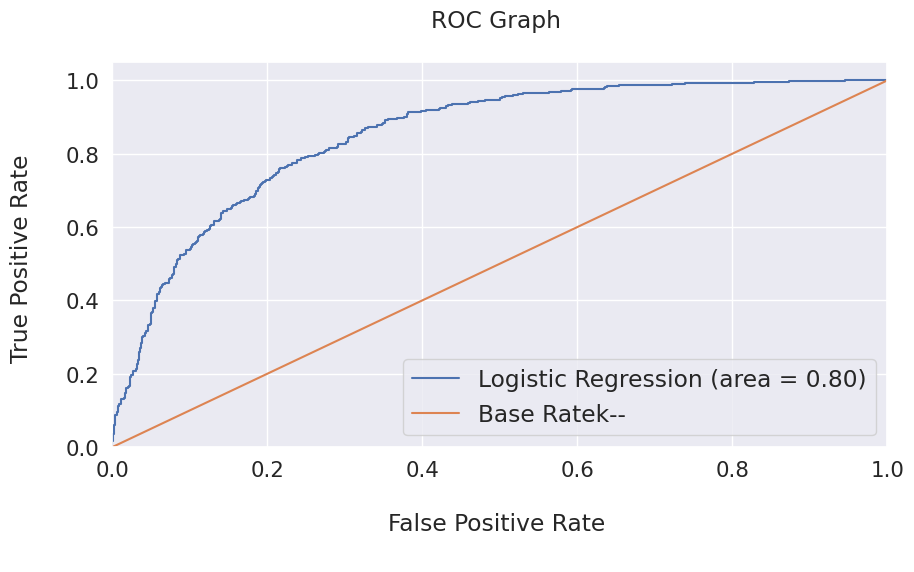

In [ ]:
# Evaluate the model using ROC Graph
from sklearn.metrics import auc, roc_auc_score, roc_curve
classifier.fit(X_train, y_train)
probs = classifier.predict_proba(X_test)
probs = probs[:, 1]
classifier_roc_auc = accuracy_score(y_test, y_pred )


rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, classifier.predict_proba(X_test)[:,1])
plt.figure(figsize=(10, 5))

# Plot Logistic Regression ROC
plt.plot(rf_fpr, rf_tpr, label='Logistic Regression (area = %0.2f)' % classifier_roc_auc)
# Plot Base Rate ROC
plt.plot([0,1], [0,1],label='Base Rate' 'k--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.ylabel('True Positive Rate \n',horizontalalignment="center")
plt.xlabel('\nFalse Positive Rate \n',horizontalalignment="center")
plt.title('ROC Graph \n',horizontalalignment="center")
plt.legend(loc="lower right", fontsize = "medium")
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")
plt.show()

In [ ]:
#----------------------------------------------------------------------------------------
#-----------------Section E: Model Improvement (Logistic Regression)----------------------------
#----------------------------------------------------------------------------------------

In [ ]:

#----------------------------------------------------------------------------------------
#-----------------Section F: Comparing Model Predictions against test set----------------
#----------------------------------------------------------------------------------------


# Handling unbalanced problem

### Using SMOTE Oversampling concept the unbalanced problem is made as balanced problem

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state = 2)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train.ravel())

In [ ]:
X_test_res, y_test_res = sm.fit_resample(X_test, y_test.ravel())

In [ ]:
X_train_res.shape

(8278, 39)

In [ ]:
# Replace X_train, y_train with resample values X_train_res, y_train_res
X_train = X_train_res
y_train = y_train_res

In [ ]:
# Replace X_test, y_test with resample values X_test_res, y_test_res
X_test = X_test_res
y_test = y_test_res

In [ ]:
y_train

array([0, 0, 0, ..., 1, 1, 1])

In [ ]:
# Count no. of 0, 1 in y_train to check the problem is balanced or not

a = np.array(y_train.tolist())
a= a.tolist()
print (a.count(0))
print (a.count(1))

4139
4139


In [ ]:
# Following code is same as is executed previously and now is executed on resampled data

#Step 15.1: Compare Baseline Classification Algorithms - First Iteration
#Using Accuracy and ROC AUC Mean Metrics

models = []

models.append(('Logistic Regression', LogisticRegression(solver='liblinear', random_state = 0, class_weight='balanced')))

models.append(('SVC', SVC(kernel = 'linear', random_state = 0)))

models.append(('Gaussian NB', GaussianNB()))

models.append(('Decision Tree Classifier', DecisionTreeClassifier(criterion = 'entropy', random_state = 0)))

models.append(('Random Forest', RandomForestClassifier(n_estimators=100, criterion = 'entropy', random_state = 0)))

#Evaluating Model Results:

acc_results = []
auc_results = []
names = []

# set table to table to populate with performance results
col = ['Algorithm', 'ROC AUC Mean', 'ROC AUC STD', 'Accuracy Mean', 'Accuracy STD']
model_results = pd.DataFrame({"Algorithm":pd.Series(dtype='str'),
                              "ROC AUC Mean" : pd.Series (dtype='float'),
                              "ROC AUC STD" : pd.Series (dtype='float'),
                              "Accuracy Mean" : pd.Series (dtype='float'),
                              "Accuracy STD" : pd.Series (dtype='float')})

In [ ]:
# i = 0
# # evaluate each model using k-fold cross-validation
# for name, model in models:
#     kfold = model_selection.KFold(n_splits=10)  # 10-fold cross-validation

#     cv_acc_results = model_selection.cross_val_score(  # accuracy scoring
#         model, X_train, y_train, cv=kfold, scoring='accuracy')

#     cv_auc_results = model_selection.cross_val_score(  # roc_auc scoring
#         model, X_train, y_train, cv=kfold, scoring='roc_auc')

#     acc_results.append(cv_acc_results)
#     auc_results.append(cv_auc_results)
#     names.append(name)
#     model_results.loc[i] = [name,
#                          round(cv_auc_results.mean()*100, 2),
#                          round(cv_auc_results.std()*100, 2),
#                          round(cv_acc_results.mean()*100, 2),
#                          round(cv_acc_results.std()*100, 2)
#                          ]
#     i += 1

# model_results.sort_values(by=['ROC AUC Mean'], ascending=False)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:794: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 115, in __call__
    score = scorer._score(cached_call, estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 399, in _score
    return self._sign * self._score_func(y, y_pred, **self._kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_ranking.py", line 572, in roc_auc_score
    return _average_binary_score(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_base.py", line 75, in _average_binary_score
    return binary_metric(y_true, y_score, sample_weight=sample_weight)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_ranking.py", line 339, in _binary_roc_auc_score

,Algorithm,ROC AUC Mean,ROC AUC STD,Accuracy Mean,Accuracy STD
0,Logistic Regression,NaN,NaN,77.54,3.34
1,SVC,NaN,NaN,73.43,4.73
2,Gaussian NB,NaN,NaN,74.85,7.65
3,Decision Tree Classifier,NaN,NaN,79.77,6.38
4,Random Forest,NaN,NaN,85.76,7.43


In [ ]:
#--Step 15.4.1. Logistic Regression-----------------

# Fitting Logistic Regression to the Training set
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

# Predicting the Train set results
y_pred_tr = classifier.predict(X_train)
#Evaluate results - train data
acc = accuracy_score(y_train, y_pred_tr)
prec = precision_score(y_train, y_pred_tr)
rec = recall_score(y_train, y_pred_tr)
f1 = f1_score(y_train, y_pred_tr)
f2 = fbeta_score(y_train, y_pred_tr, beta=2.0)

train_results = pd.DataFrame([['Logistic Regression', acc, prec, rec, f1, f2]],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score'])

# Predicting the Test set results
y_pred = classifier.predict(X_test)

#Evaluate results - test data
acc = accuracy_score(y_test, y_pred )
prec = precision_score(y_test, y_pred )
rec = recall_score(y_test, y_pred )
f1 = f1_score(y_test, y_pred )
f2 = fbeta_score(y_test, y_pred, beta=2.0)

results = pd.DataFrame([['Logistic Regression', acc, prec, rec, f1, f2]],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score'])

#Step 15.4.2. . Support Vector Machine (linear classifier)------------------------
# Fitting SVM (SVC class) to the Training set:

classifier = SVC(kernel = 'linear', random_state = 0)
classifier.fit(X_train, y_train)

# Predicting the Train set results
y_pred_tr = classifier.predict(X_train)

#Evaluate results - train data
acc = accuracy_score(y_train, y_pred_tr)
prec = precision_score(y_train, y_pred_tr)
rec = recall_score(y_train, y_pred_tr)
f1 = f1_score(y_train, y_pred_tr)
f2 = fbeta_score(y_train, y_pred_tr, beta=2.0)

model_results = pd.DataFrame([['SVM (Linear)', acc, prec, rec, f1, f2]],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score'])
#train_results = train_results.append (model_results, ignore_index = True)
train_results = pd.concat ([train_results,model_results],ignore_index=True)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

#Evaluate results Test data
acc = accuracy_score(y_test, y_pred )
prec = precision_score(y_test, y_pred )
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred )
f2 = fbeta_score(y_test, y_pred, beta=2.0)

model_results = pd.DataFrame([['SVM (Linear)', acc, prec, rec, f1, f2]],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score'])

#results = results.append(model_results, ignore_index = True)
results = pd.concat ([results,model_results],ignore_index=True)

#Step 15.4.5.  Naive Byes------------------------------------------------

# Fitting Naive Byes to the Training set:
classifier = GaussianNB()
classifier.fit(X_train, y_train)

# Predicting the Train set results
y_pred_tr = classifier.predict(X_train)

#Evaluate results - train data
acc = accuracy_score(y_train, y_pred_tr)
prec = precision_score(y_train, y_pred_tr)
rec = recall_score(y_train, y_pred_tr)
f1 = f1_score(y_train, y_pred_tr)
f2 = fbeta_score(y_train, y_pred_tr, beta=2.0)

model_results = pd.DataFrame([['Naive Byes', acc, prec, rec, f1, f2]],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score'])
#train_results = train_results.append (model_results, ignore_index = True)
train_results = pd.concat ([train_results,model_results],ignore_index=True)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

#Evaluate results - Test data
acc = accuracy_score(y_test, y_pred )
prec = precision_score(y_test, y_pred )
rec = recall_score(y_test, y_pred )
f1 = f1_score(y_test, y_pred )
f2 = fbeta_score(y_test, y_pred, beta=2.0)

model_results = pd.DataFrame([['Naive Byes', acc, prec, rec, f1, f2]],
                columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score'])

#results = results.append(model_results, ignore_index = True)
results = pd.concat ([results,model_results],ignore_index=True)

#Step 15.4.6. Decision Tree---------------------------------------------

# Fitting Decision Tree to the Training set:
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

# Predicting the Train set results
y_pred_tr = classifier.predict(X_train)

#Evaluate results - train data
acc = accuracy_score(y_train, y_pred_tr)
prec = precision_score(y_train, y_pred_tr)
rec = recall_score(y_train, y_pred_tr)
f1 = f1_score(y_train, y_pred_tr)
f2 = fbeta_score(y_train, y_pred_tr, beta=2.0)

model_results = pd.DataFrame([['Decision Tree', acc, prec, rec, f1, f2]],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score'])
#train_results = train_results.append (model_results, ignore_index = True)
train_results = pd.concat ([train_results,model_results],ignore_index=True)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

#Evaluate results - Test data
acc = accuracy_score(y_test, y_pred )
prec = precision_score(y_test, y_pred )
rec = recall_score(y_test, y_pred )
f1 = f1_score(y_test, y_pred )
f2 = fbeta_score(y_test, y_pred, beta=2.0)

model_results = pd.DataFrame([['Decision Tree', acc, prec, rec, f1, f2]],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score'])

#results = results.append(model_results, ignore_index = True)
results = pd.concat ([results,model_results],ignore_index=True)

#Step 15.4.7. Random Forest--------------------------------------------

# Fitting Random Forest to the Training set:
classifier = RandomForestClassifier(n_estimators = 84, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

# Predicting the Train set results
y_pred_tr = classifier.predict(X_train)

#Evaluate results - train data
acc = accuracy_score(y_train, y_pred_tr)
prec = precision_score(y_train, y_pred_tr)
rec = recall_score(y_train, y_pred_tr)
f1 = f1_score(y_train, y_pred_tr)
f2 = fbeta_score(y_train, y_pred_tr, beta=2.0)

model_results = pd.DataFrame([['Random Forest', acc, prec, rec, f1, f2]],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score'])
#train_results = train_results.append (model_results, ignore_index = True)
train_results = pd.concat ([train_results,model_results],ignore_index=True)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

#Evaluate results - Test data
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
acc = accuracy_score(y_test, y_pred )
prec = precision_score(y_test, y_pred )
rec = recall_score(y_test, y_pred )
f1 = f1_score(y_test, y_pred )
f2 = fbeta_score(y_test, y_pred, beta=2.0)

model_results = pd.DataFrame([['Random Forest', acc, prec, rec, f1, f2]],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'F2 Score'])

#results = results.append(model_results, ignore_index = True)
results = pd.concat ([results,model_results],ignore_index=True)

In [ ]:
train_results = train_results.sort_values (["Precision", "Recall", "F2 Score"], ascending = False)

In [ ]:
train_results

,Model,Accuracy,Precision,Recall,F1 Score,F2 Score
3,Decision Tree,0.997946,0.999758,0.996134,0.997943,0.996857
4,Random Forest,0.997946,0.998067,0.997826,0.997946,0.997874
0,Logistic Regression,0.776033,0.761024,0.804784,0.782292,0.795634
1,SVM (Linear),0.746920,0.707302,0.842474,0.768993,0.811459
2,Naive Byes,0.748128,0.704337,0.855279,0.772504,0.820128


In [ ]:
#Step 15.5. Visualize the results and compare the baseline algorithms----------------------------------

# =======================================================================================================================
#Sort results based on the right classification metric:
#(Accuracy/ROC_AUC / Precision/Recall/F1/F2 scores)

#Since we have class imbalance. When we look into the business challenge,
# our false negatives will be costly and hence we need to Keep an eye onto the Precision, Recall & F2 score besides accuracy
# =======================================================================================================================

results = results.sort_values(["Precision", "Recall", "F2 Score"], ascending = False)
results

,Model,Accuracy,Precision,Recall,F1 Score,F2 Score
4,Random Forest,0.803865,0.837809,0.753623,0.793489,0.769079
3,Decision Tree,0.747343,0.778261,0.691787,0.732481,0.707510
0,Logistic Regression,0.787923,0.769928,0.821256,0.794764,0.810450
2,Naive Byes,0.761836,0.718196,0.861836,0.783487,0.828688
1,SVM (Linear),0.745894,0.709810,0.831884,0.766014,0.804222
